#***Question***

Dataset Overview
Load the dataset House_Pricing.csv
Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values.

Duplicate Removal
Rows: Check for duplicate rows in the dataset, if any, and remove them.
Columns: Identify and drop duplicate columns, if any, based on their values.
Handling Missing Values

Identify missing values in each column.
Handle missing values:
For numerical columns, use imputation techniques like mean/median imputation.
For categorical columns, fill with mode.
Document your approach for each feature with missing data.
Scaling Numerical Variables
Identify all numerical columns (excluding the target variable SalePrice).

Scale these features using techniques like Min-Max scaling or Standard scaling.

Encoding Categorical Variables
Identify all categorical columns in the dataset.
Apply appropriate encoding techniques:
Use One-Hot Encoding for nominal categories.
Use Label Encoding for ordinal categories, if applicable.
Outlier Removal

Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).
Remove outliers from these features if they are not representative of typical house prices.

Train-Test Split
Set aside the SalePrice column as the target variable.
Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.

Submission: Upload the completed notebook to your GitHub and share the link of the same here.

#***Libraries***

In [2]:
import numpy as np                                        # numerical calculation
import pandas as pd                                       # data manipulation
import matplotlib.pyplot as plt                           # data visualization
import seaborn as sns                                     # data visualization
from statistics import mode                               # mode function

from sklearn.preprocessing import MinMaxScaler,StandardScaler           # Minmax scalar ----> skewed columns , Standard scalar -----------> Symmetric columns

from sklearn.preprocessing import LabelEncoder,OneHotEncoder            # Labelencoder -----> continuous target and binary feature , Onehot encoder ----> Discrete features

from sklearn.model_selection import train_test_split

#***Reading Dataset***

In [3]:
# path of datasest
filepath = '/content/drive/MyDrive/ICT AIML/Datasets/House_Pricing.csv'
# reading file
df_house_price = pd.read_csv(filepath)
# checking if file is loaded correctly
df_house_price.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


#***Preprocessing***

##***EDA***

In [4]:
#.info()
# to display datatypes of various columns
df_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [5]:
#.describe()
# to describe the statistical summary of various columns
df_house_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


##***Data Cleaning***

###***Duplicate Removal***

In [6]:
# duplicate rows
df_house_price.duplicated().sum()

np.int64(0)

In [7]:
# duplicated columns
df_house_price.T.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Correlation Heatmap')

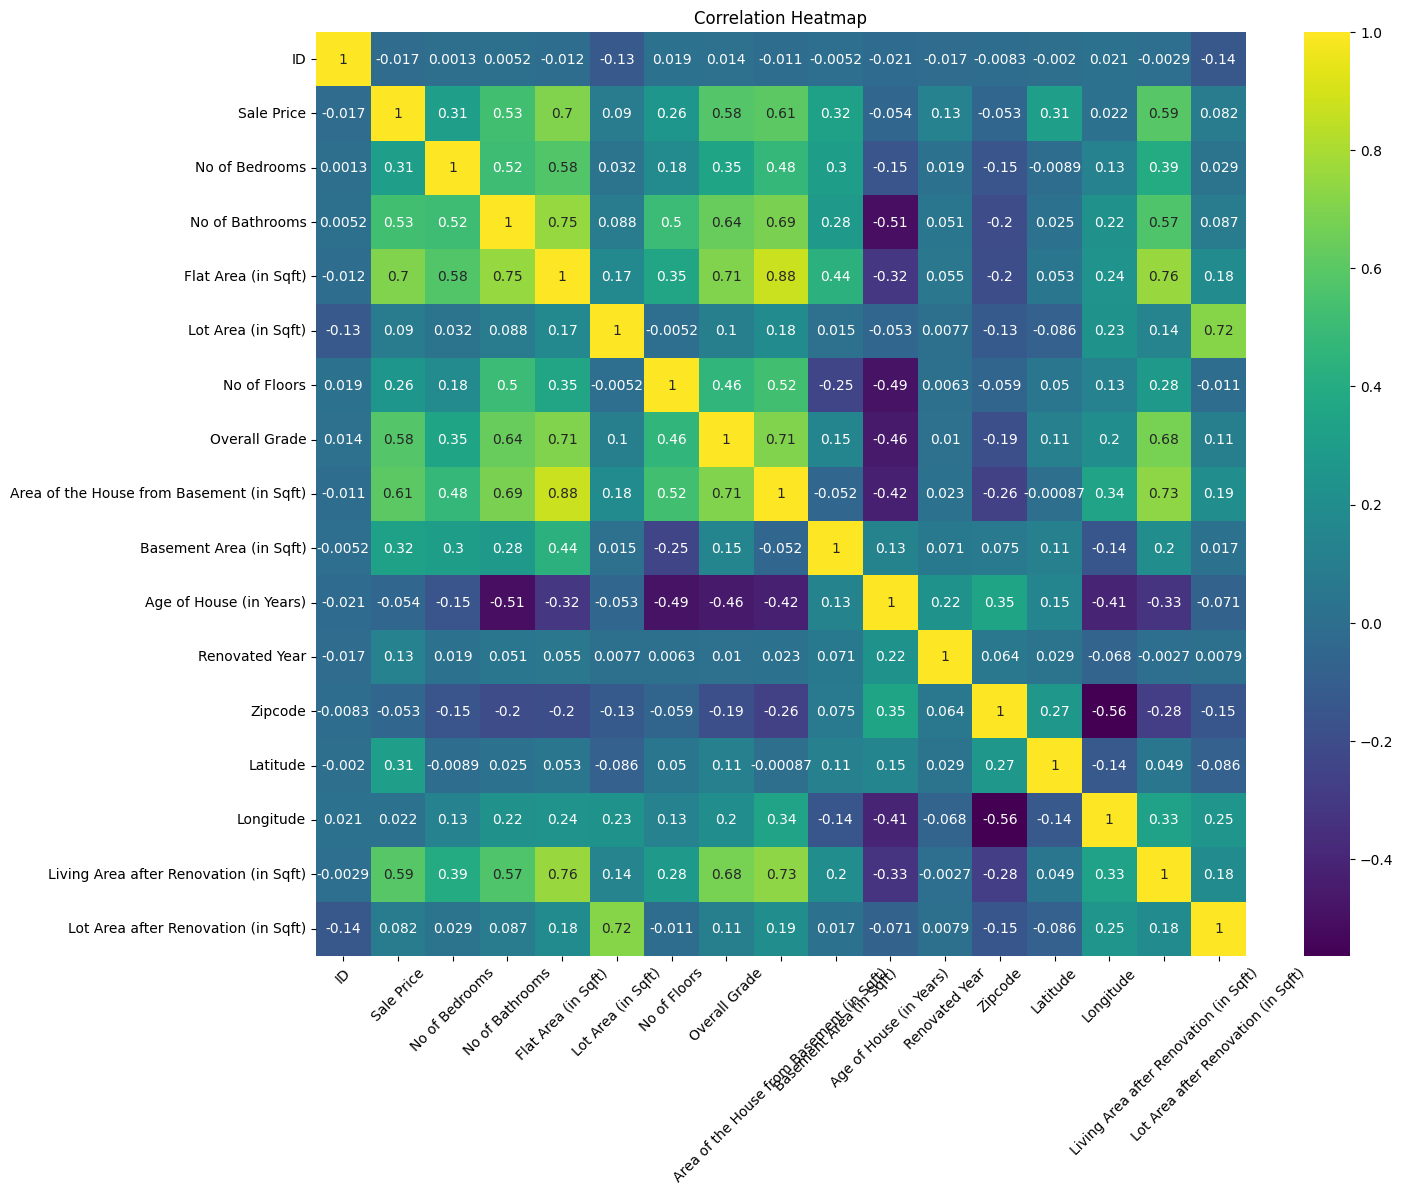

In [8]:
# correation matrix

num_cols = df_house_price.select_dtypes(include = np.number)
corr_mat = num_cols.corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr_mat, annot = True, cmap = 'viridis', fmt ='.2g' )
plt.xticks(rotation = 45)
plt.title('Correlation Heatmap')

###***Missing value handling***

In [9]:
# No.of misssing values
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [10]:
# Since sale price is target column we do not need to manipulate the target so we remove that rows
df_house_price = df_house_price.dropna(subset = ['Sale Price'])
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485


<Axes: xlabel='No of Bathrooms', ylabel='Density'>

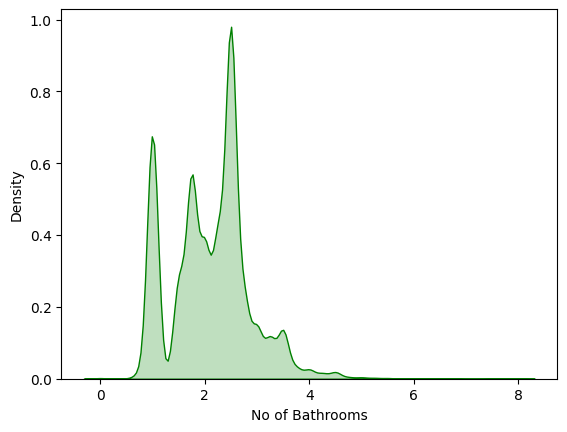

In [11]:
# No of Bathrooms has 4 missing values so we plot the distribution to identify if we need to fill with mean or median value
# Since the distribution is skewed so we cant fill with mean so we use median
sns.kdeplot(df_house_price['No of Bathrooms'],fill = True , color = 'g')

In [12]:
df_house_price['No of Bathrooms'].fillna(df_house_price['No of Bathrooms'].median(), inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/3827952139.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['No of Bathrooms'].fillna(df_house_price['No of Bathrooms'].median(), inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485


<Axes: xlabel='Flat Area (in Sqft)', ylabel='Density'>

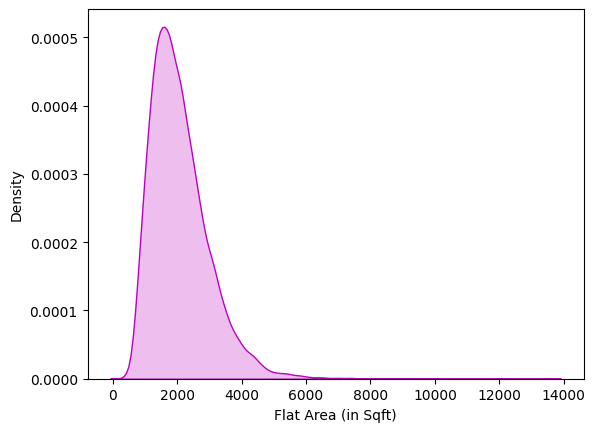

In [13]:
# Flat Area (in Sqft) has 9 missing values so we plot the distribution to identify if we need to fill with mean or median value
# Since the distribution is skewed so we cant fill with mean so we use median

sns.kdeplot(df_house_price['Flat Area (in Sqft)'], fill = True , color = 'm')


In [14]:
df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median() , inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/3084441515.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median() , inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485


<Axes: xlabel='Lot Area (in Sqft)', ylabel='Density'>

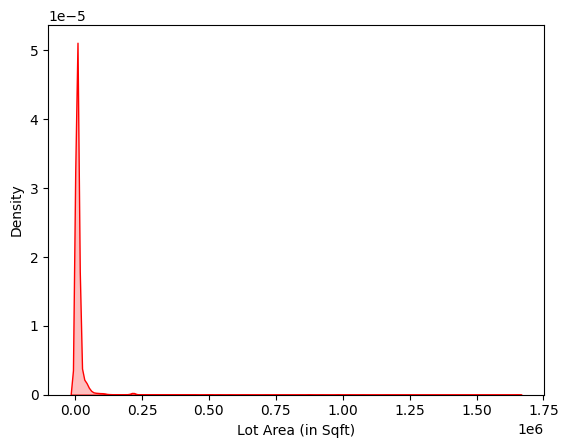

In [15]:
# Lot Area (in Sqft) has 9 missing values so we plot the distribution to identify if we need to fill with mean or median value
# Since the distribution is skewed so we cant fill with mean so we use median

sns.kdeplot(df_house_price['Lot Area (in Sqft)'], fill = True , color = 'r')

In [16]:
df_house_price['Lot Area (in Sqft)'].fillna(df_house_price['Lot Area (in Sqft)'].median(), inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/3061609537.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Lot Area (in Sqft)'].fillna(df_house_price['Lot Area (in Sqft)'].median(), inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19485


In [17]:
# No of Times Visited column contain large no  of missing value it is better to drop this column rather than filling it so we drop it

df_house_price.drop(columns = ['No of Times Visited'] , inplace = True)
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Area of the House from Basement (in Sqft)', ylabel='Density'>

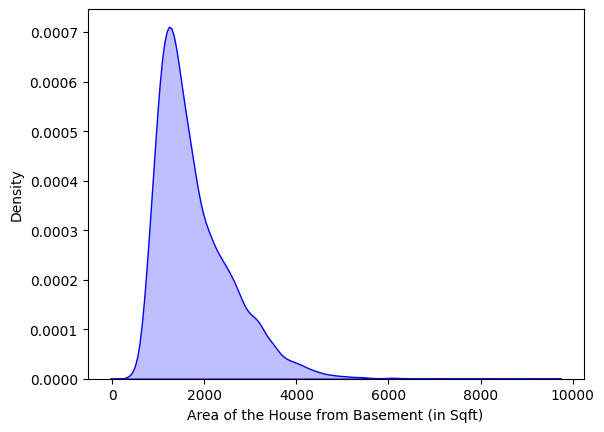

In [18]:
# Area of the House from Basement (in Sqft) has 3 missing values so we plot the distribution to identify if we need to fill with mean or median value
# Since the distribution is skewed so we cant fill with mean so we use median

sns.kdeplot(df_house_price['Area of the House from Basement (in Sqft)'], fill = True , color = 'b')

In [19]:
df_house_price['Area of the House from Basement (in Sqft)'].fillna(df_house_price['Area of the House from Basement (in Sqft)'].median(), inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/3011895570.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Area of the House from Basement (in Sqft)'].fillna(df_house_price['Area of the House from Basement (in Sqft)'].median(), inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Zipcode', ylabel='Density'>

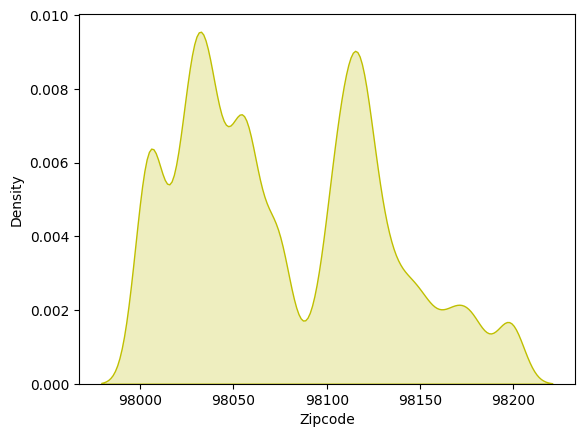

In [20]:
# Zipcode has 1 missing value s
# Since the zipcode has discrerte values or categorical we can fill by mode only

sns.kdeplot(df_house_price['Zipcode'], fill = True , color = 'y')

In [21]:
df_house_price['Zipcode'].fillna(mode(df_house_price['Zipcode']), inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/2420412500.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Zipcode'].fillna(mode(df_house_price['Zipcode']), inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Latitude', ylabel='Density'>

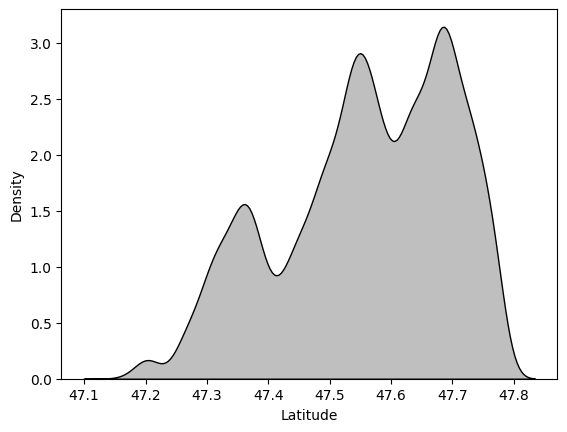

In [22]:
# Latitude has 1 missing value so we plot the distribution to identify if we need to fill with mean or median value
# Since the distribution is skewed so we cant fill with mean so we use median

sns.kdeplot(df_house_price['Latitude'], fill = True , color = 'k')

In [23]:
df_house_price['Latitude'].fillna(df_house_price['Latitude'].median(), inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/2255138373.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Latitude'].fillna(df_house_price['Latitude'].median(), inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Longitude', ylabel='Density'>

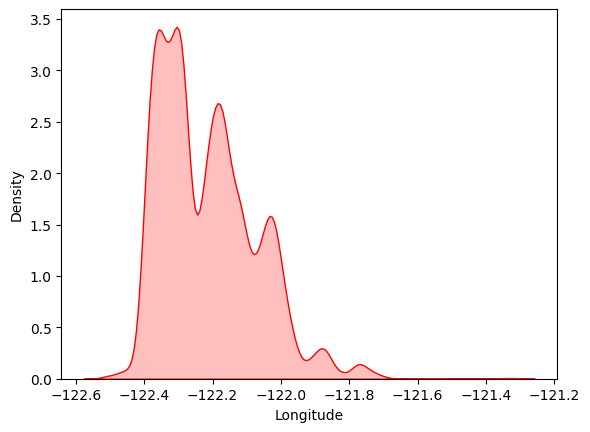

In [24]:
# Longitude has 1 missing value so we plot the distribution to identify if we need to fill with mean or median value
# Since the distribution is skewed so we cant fill with mean so we use median

sns.kdeplot(df_house_price['Longitude'], fill = True , color = 'r')

In [25]:
df_house_price['Longitude'].fillna(df_house_price['Longitude'].median(), inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/2175077859.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Longitude'].fillna(df_house_price['Longitude'].median(), inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Living Area after Renovation (in Sqft)', ylabel='Density'>

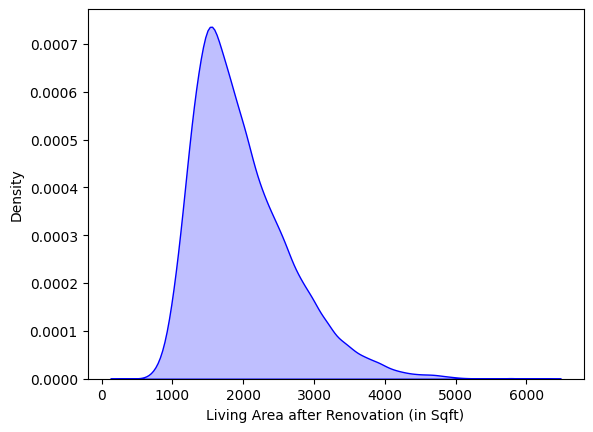

In [26]:
# Living Area after Renovation (in Sqft) has 1 missing value so we plot the distribution to identify if we need to fill with mean or median value
# Since the distribution is skewed so we cant fill with mean so we use median

sns.kdeplot(df_house_price['Living Area after Renovation (in Sqft)'], fill = True , color = 'b')

In [27]:
df_house_price['Living Area after Renovation (in Sqft)'].fillna(df_house_price['Living Area after Renovation (in Sqft)'].median(), inplace = True)
df_house_price.isna().sum()

/tmp/ipykernel_1801/157880506.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Living Area after Renovation (in Sqft)'].fillna(df_house_price['Living Area after Renovation (in Sqft)'].median(), inplace = True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


###***Outlier Handling***

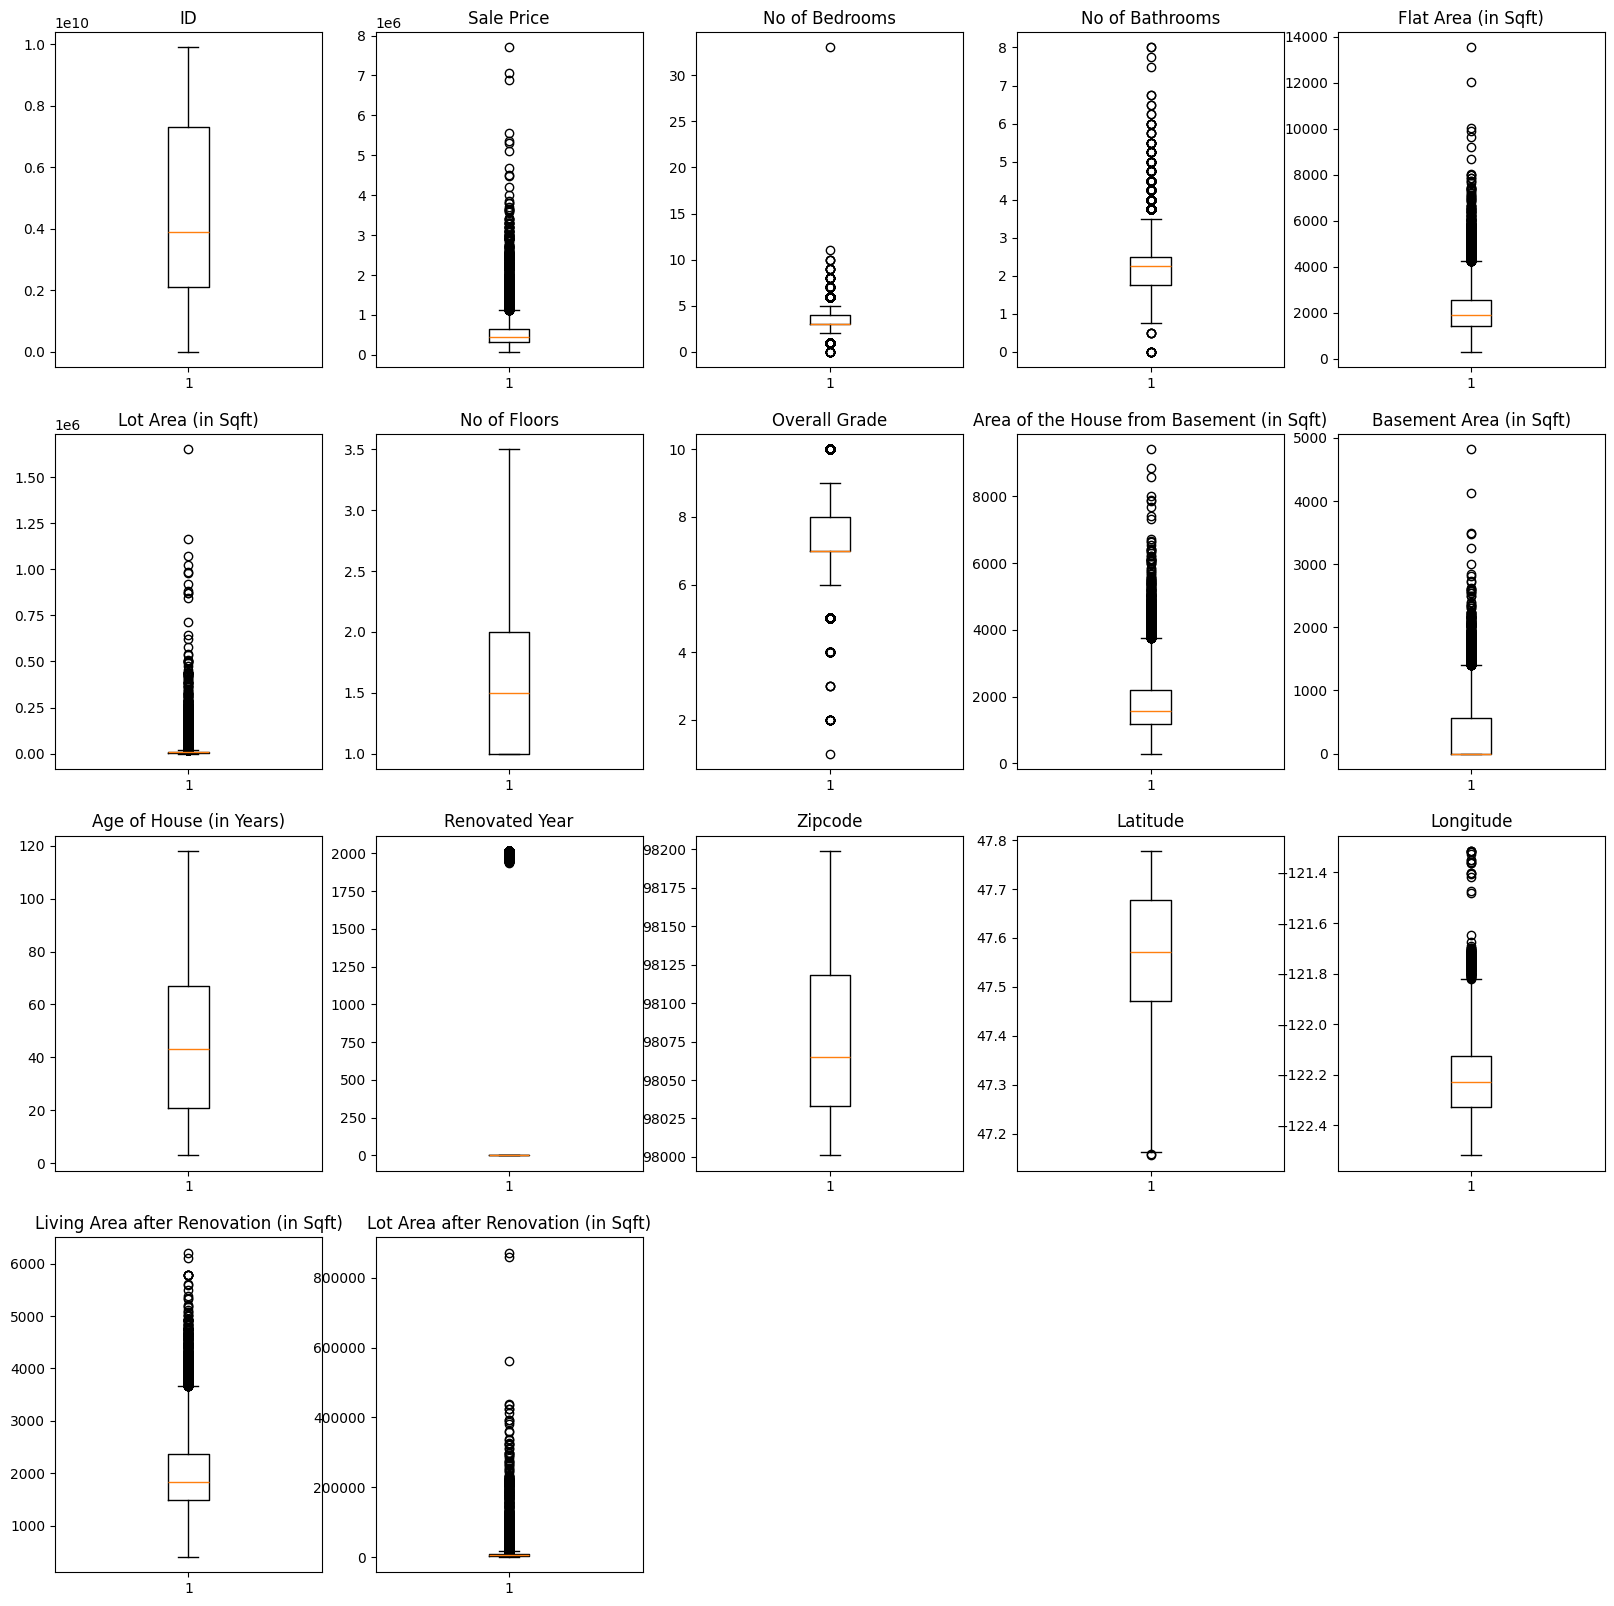

In [28]:
plt.figure(figsize = (20,20))
for i,id in enumerate(num_cols,1):
  plt.subplot(4,5,i)
  plt.boxplot(df_house_price[id])
  plt.title(id)

In [29]:
df_house_price['Sale Price'] = np.log1p(df_house_price['Sale Price'])       # since sales price is highly right skewed we use log transformation

In [30]:
# Fetching columns that need outlier removal
outlier_cols = [
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Basement Area (in Sqft)',
    'Living Area after Renovation (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
]

for col in outlier_cols:

    Q1 = df_house_price[col].quantile(0.25) # first quartile
    Q3 = df_house_price[col].quantile(0.75) # third quartile

    IQR = Q3 - Q1                            # calculation of inter quartile range

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_house_price[(df_house_price[col] < lower_bound) | (df_house_price[col] > upper_bound)]    # values less than lowerbound or values greater than upper bound is called outliers

    print(f"{col}: {len(outliers)} outliers")

    df_house_price[col] = df_house_price[col].clip(lower=lower_bound, upper=upper_bound) # clipping of outliers

Flat Area (in Sqft): 572 outliers
Lot Area (in Sqft): 2423 outliers
Area of the House from Basement (in Sqft): 610 outliers
Basement Area (in Sqft): 496 outliers
Living Area after Renovation (in Sqft): 544 outliers
Lot Area after Renovation (in Sqft): 2193 outliers


##***Transformations***

###***Scaling***

In [31]:
df_house_price.describe()
# comparing min and max values of each column to decide which are to be scaled

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.160900e+04,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000
mean,4.580686e+09,13.047904,3.370771,2.114709,2057.928224,8704.844579,1.494215,7.623490,1769.501874,284.053219,46.999722,84.417881,98077.940488,47.560050,-122.213875,1975.111481,8298.894350
std,2.876653e+09,0.526846,0.929916,0.770097,838.881155,5044.601914,0.539909,1.105519,763.929455,417.055460,29.373317,401.714775,53.506305,0.138556,0.140832,649.030387,4364.106836
min,1.000102e+06,11.225257,0.000000,0.000000,290.000000,520.000000,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,12.682155,3.000000,1.750000,1430.000000,5040.000000,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904931e+09,13.017005,3.000000,2.250000,1910.000000,7619.000000,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,13.377007,4.000000,2.500000,2550.000000,10687.000000,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10084.000000
max,9.900000e+09,15.856731,33.000000,8.000000,4230.000000,19157.500000,3.500000,10.000000,3740.000000,1400.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,3665.000000,17560.000000


In [32]:
# Fetching numerical columns

numerical_col = df_house_price.select_dtypes(include=['int64', 'float64']).columns
print(numerical_col)

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [33]:
# skewed columns to be scaled using a minmax scalar
skew_cols =['No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)','Area of the House from Basement (in Sqft)','Basement Area (in Sqft)','Living Area after Renovation (in Sqft)','Lot Area after Renovation (in Sqft)']

In [34]:
# before scaling
df_house_price.head()


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,12.309987,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,13.195616,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,12.100718,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,13.311331,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,13.142168,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [35]:
# minmax scaling
scaler = MinMaxScaler()                                                         # scalar object creation
df_house_price[skew_cols] = scaler.fit_transform(df_house_price[skew_cols])
df_house_price.head()                                                           # after scaling


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,12.309987,3,0.12500,0.225888,0.275252,1.0,No,Fair,7,0.257971,0.000000,63,0,98178.0,47.5112,-122.257,0.288120,0.295641
1,6414100192,14 December 2017,13.195616,3,0.28125,0.578680,0.360671,2.0,No,Fair,7,0.544928,0.285714,67,1991,98125.0,47.7210,-122.319,0.395285,0.413271
2,5631500400,15 February 2016,12.100718,2,0.12500,0.121827,0.508652,1.0,No,Fair,6,0.139130,0.000000,85,0,98028.0,47.7379,-122.233,0.710655,0.438287
3,2487200875,14 December 2017,13.311331,4,0.37500,0.423858,0.240376,1.0,No,Excellent,7,0.220290,0.650000,53,0,98136.0,47.5208,-122.393,0.294244,0.257200
4,1954400510,15 February 2016,13.142168,3,0.25000,0.352792,0.405634,1.0,No,Fair,8,0.402899,0.000000,31,0,98074.0,47.6168,-122.045,0.428965,0.405228


In [36]:
# There is no perfectly symmetric distribution to be scaled using standard scalar

###***Encoding***

In [37]:
# Fetching Categorical columns

cat_cols = df_house_price.select_dtypes(include = ['object']).columns
print(cat_cols)

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


####***Onehot Encoding***

In [38]:
print(cat_cols)
ohe_cols = ['Date House was Sold','Condition of the House']                         # selected categorical columns to perform ohe
df_house_price = pd.get_dummies(df_house_price, columns = ohe_cols ,drop_first=True, dtype = int)
df_house_price.head()

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),...,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,12.309987,3,0.12500,0.225888,0.275252,1.0,No,7,0.257971,...,0,0,0,0,0,0,0,1,0,0
1,6414100192,13.195616,3,0.28125,0.578680,0.360671,2.0,No,7,0.544928,...,0,0,0,0,0,0,0,1,0,0
2,5631500400,12.100718,2,0.12500,0.121827,0.508652,1.0,No,6,0.139130,...,0,0,1,0,0,0,0,1,0,0
3,2487200875,13.311331,4,0.37500,0.423858,0.240376,1.0,No,7,0.220290,...,0,0,0,0,0,0,1,0,0,0
4,1954400510,13.142168,3,0.25000,0.352792,0.405634,1.0,No,8,0.402899,...,0,0,1,0,0,0,0,1,0,0


In [39]:
df_house_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 34 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Sale Price                                 21609 non-null  float64
 2   No of Bedrooms                             21609 non-null  int64  
 3   No of Bathrooms                            21609 non-null  float64
 4   Flat Area (in Sqft)                        21609 non-null  float64
 5   Lot Area (in Sqft)                         21609 non-null  float64
 6   No of Floors                               21609 non-null  float64
 7   Waterfront View                            21609 non-null  object 
 8   Overall Grade                              21609 non-null  int64  
 9   Area of the House from Basement (in Sqft)  21609 non-null  float64
 10  Basement Area (in Sqft)    

####***Label Encoding***



In [40]:
df_house_price.head() # before encoding

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),...,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,12.309987,3,0.12500,0.225888,0.275252,1.0,No,7,0.257971,...,0,0,0,0,0,0,0,1,0,0
1,6414100192,13.195616,3,0.28125,0.578680,0.360671,2.0,No,7,0.544928,...,0,0,0,0,0,0,0,1,0,0
2,5631500400,12.100718,2,0.12500,0.121827,0.508652,1.0,No,6,0.139130,...,0,0,1,0,0,0,0,1,0,0
3,2487200875,13.311331,4,0.37500,0.423858,0.240376,1.0,No,7,0.220290,...,0,0,0,0,0,0,1,0,0,0
4,1954400510,13.142168,3,0.25000,0.352792,0.405634,1.0,No,8,0.402899,...,0,0,1,0,0,0,0,1,0,0


In [41]:
label_encoder_obj = LabelEncoder()
df_house_price['Waterfront View']= label_encoder_obj.fit_transform(df_house_price['Waterfront View'])     # waterfront View is a binary feature so we used label encoding
df_house_price.head()


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),...,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,12.309987,3,0.12500,0.225888,0.275252,1.0,0,7,0.257971,...,0,0,0,0,0,0,0,1,0,0
1,6414100192,13.195616,3,0.28125,0.578680,0.360671,2.0,0,7,0.544928,...,0,0,0,0,0,0,0,1,0,0
2,5631500400,12.100718,2,0.12500,0.121827,0.508652,1.0,0,6,0.139130,...,0,0,1,0,0,0,0,1,0,0
3,2487200875,13.311331,4,0.37500,0.423858,0.240376,1.0,0,7,0.220290,...,0,0,0,0,0,0,1,0,0,0
4,1954400510,13.142168,3,0.25000,0.352792,0.405634,1.0,0,8,0.402899,...,0,0,1,0,0,0,0,1,0,0


#***Training and Test***

In [42]:
# Target column is Sale Price
y =df_house_price['Sale Price']


# All other columns except sale price are features
X = df_house_price.drop('Sale Price', axis = 1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)



print("Training set shape : ",X_train.shape)
print("Testing set shape : ",X_test.shape)


Training set shape :  (17287, 33)
Testing set shape :  (4322, 33)
